# Car Price Prediction with Machine Learning
**Track:** Data Science | **Task 3**

**Objective:** Build regression models that predict the selling price of a used car from features such as brand, age, mileage, fuel type and transmission.

**Dataset:** *Vehicle dataset from CarDekho* (Kaggle) - file `CAR DETAILS FROM CAR DEKHO.csv`, stored in the `data/` folder. Prices are in **Indian Rupees (INR)**.

**Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Outline**
1. Import libraries and load data
2. Data cleaning
3. Feature engineering (car age, brand)
4. Exploratory Data Analysis
5. Encode categorical variables
6. Correlation heatmap
7. Train/test split
8. Train regression models
9. Evaluate (MAE, RMSE, R2)
10. Feature importance of the best model
11. Predict the price of a new car

## 1. Import Libraries and Load Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format
RANDOM_STATE = 42

In [2]:
# Load the dataset (the CSV is in the data/ folder next to this notebook)
df = pd.read_csv("data/CAR DETAILS FROM CAR DEKHO.csv")

print("Shape:", df.shape)
df.head()

Shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 2. Data Cleaning

### 2.1 Structure and data types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


### 2.2 Null values

In [4]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Total missing values: 0


The dataset has no null values. The code below still drops any null rows, so the notebook also works if you use a different version of the dataset.

In [5]:
rows_before = len(df)
df = df.dropna()
print(f"Rows removed because of nulls: {rows_before - len(df)}")

Rows removed because of nulls: 0


### 2.3 Duplicate rows

In [6]:
print("Duplicate rows found:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 763
Shape after removing duplicates: (3577, 8)


### 2.4 Inconsistent categorical values
We check each categorical column for spelling or capitalisation differences (for example `Petrol` vs `petrol`) and standardise them.

In [7]:
cat_cols = ["fuel", "seller_type", "transmission", "owner"]

print("BEFORE cleaning:")
for col in cat_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

# Remove stray spaces and standardise capitalisation (e.g. 'petrol ' -> 'Petrol')
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Combine tiny, rare categories that would add noise
df["owner"] = df["owner"].replace({"Test Drive Car": "First Owner"})

print("\nAFTER cleaning:")
for col in cat_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

BEFORE cleaning:
  fuel: ['CNG', 'Diesel', 'Electric', 'LPG', 'Petrol']
  seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
  transmission: ['Automatic', 'Manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']

AFTER cleaning:
  fuel: ['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol']
  seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
  transmission: ['Automatic', 'Manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Third Owner']


All categories are now consistent. (*Test Drive Car* entries are demo cars with almost no usage, so they are grouped with *First Owner*.)

### 2.5 Impossible or extreme values

In [8]:
df[["year", "selling_price", "km_driven"]].describe()

,year,selling_price,km_driven
count,"3,577.00","3,577.00","3,577.00"
mean,"2,012.96","473,912.54","69,250.55"
std,4.25,"509,301.81","47,579.94"
min,"1,992.00","20,000.00",1.00
25%,"2,010.00","200,000.00","36,000.00"
50%,"2,013.00","350,000.00","60,000.00"
75%,"2,016.00","600,000.00","90,000.00"
max,"2,020.00","8,900,000.00","806,599.00"


In [9]:
# A few cars have implausible mileage (over 500,000 km), which are likely data-entry errors
extreme = df[df["km_driven"] > 500_000]
print(f"Rows with km_driven > 500,000: {len(extreme)}")
display(extreme)

df = df[df["km_driven"] <= 500_000].reset_index(drop=True)
print("Shape after removing them:", df.shape)

Rows with km_driven > 500,000: 2


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
510,Maruti SX4 S Cross DDiS 320 Delta,2016,665000,560000,Diesel,Dealer,Manual,First Owner
1101,Maruti Swift VXI BSIII,2009,250000,806599,Petrol,Dealer,Manual,First Owner


Shape after removing them: (3575, 8)


High selling prices (Mercedes, BMW, Audi, ...) are **real luxury cars**, not errors, so they are kept.

## 3. Feature Engineering

### 3.1 Car age (from the year column)
Age is more meaningful to a model than the raw year. `car_age = reference year - manufacturing year`.

The listings in this dataset were collected around **2020** (the newest car is from 2020), so age is measured **as of 2020**. This keeps ages realistic (0 to about 28 years) and matches the 2020-era prices. Using today's year would make every car look at least 6 years old, and the model would have no examples of "young" cars.

In [10]:
REFERENCE_YEAR = df["year"].max()      # 2020: when the listings were collected
df["car_age"] = REFERENCE_YEAR - df["year"]

print("Reference year:", REFERENCE_YEAR)
df[["year", "car_age"]].head()

Reference year: 2020


,year,car_age
0,2007,13
1,2007,13
2,2012,8
3,2017,3
4,2014,6


### 3.2 Brand (from the car name column)
The brand is the first word of the car name, for example `Maruti Swift VXI` gives `Maruti`.

In [11]:
df["brand"] = df["name"].str.split().str[0]

# Fix names where the first word is not the full brand
df["brand"] = df["brand"].replace({"Land": "Land Rover", "OpelCorsa": "Opel"})

print(df["brand"].value_counts())

brand
Maruti           1070
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land Rover          5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
Opel                2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64


In [12]:
# Brands with very few cars cannot be learned reliably, so group them as 'Other'
MIN_CARS = 20
brand_counts = df["brand"].value_counts()
rare_brands = brand_counts[brand_counts < MIN_CARS].index
df["brand"] = df["brand"].replace(rare_brands, "Other")

print("Grouped into 'Other':", list(rare_brands))
print("\nBrands used:", df["brand"].nunique())

# The raw name and year are no longer needed
df = df.drop(columns=["name", "year"])
df.head()

Grouped into 'Other': ['Jaguar', 'Mitsubishi', 'Land Rover', 'Volvo', 'Jeep', 'Ambassador', 'MG', 'Opel', 'Daewoo', 'Force', 'Isuzu', 'Kia']

Brands used: 18


,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,60000,70000,Petrol,Individual,Manual,First Owner,13,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,13,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,8,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,3,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,6,Honda


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution of selling prices

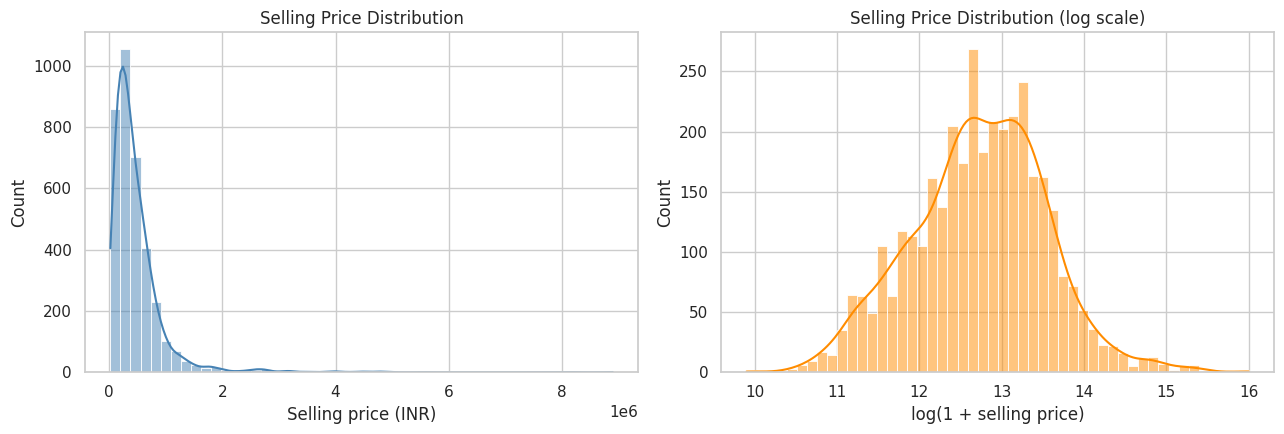

Median price: 350,000 INR
Mean price  : 473,922 INR


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["selling_price"], bins=50, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Selling Price Distribution")
axes[0].set_xlabel("Selling price (INR)")

sns.histplot(np.log1p(df["selling_price"]), bins=50, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Selling Price Distribution (log scale)")
axes[1].set_xlabel("log(1 + selling price)")

plt.tight_layout()
plt.show()

print(f"Median price: {df['selling_price'].median():,.0f} INR")
print(f"Mean price  : {df['selling_price'].mean():,.0f} INR")

**Observation:** Prices are strongly **right-skewed**. Most cars sell for a few hundred thousand rupees, while a small number of luxury cars sell for millions. The mean is therefore well above the median. On a log scale the shape is much closer to a normal distribution.

### 4.2 Price vs fuel type (box plots)

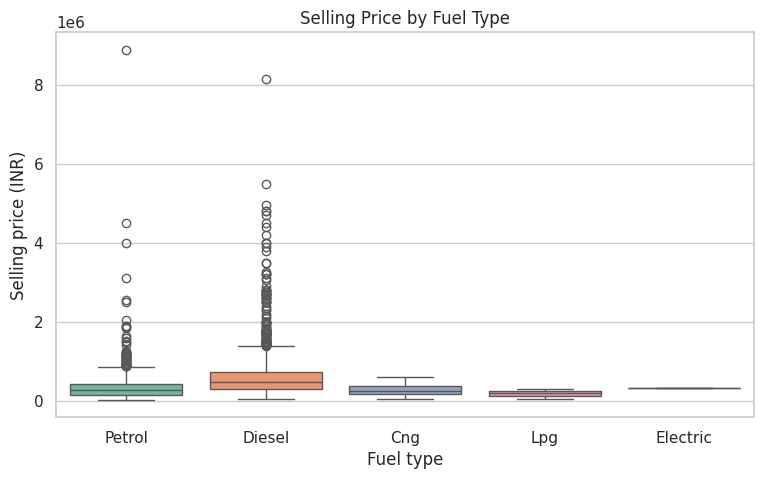

          count     median       mean
fuel                                 
Cng          37 229,999.00 273,162.00
Diesel     1799 475,000.00 613,973.00
Electric      1 310,000.00 310,000.00
Lpg          22 180,000.00 171,818.00
Petrol     1716 260,000.00 335,394.00


In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="fuel", y="selling_price", palette="Set2")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel type")
plt.ylabel("Selling price (INR)")
plt.show()

print(df.groupby("fuel")["selling_price"].agg(["count", "median", "mean"]).round(0))

**Observation:** Diesel cars have a higher median price than petrol cars, partly because diesel is more common on larger, more expensive models such as SUVs. CNG and LPG cars are cheaper, but there are very few of them, so those groups are less reliable.

### 4.3 Price vs car age (scatter plot)

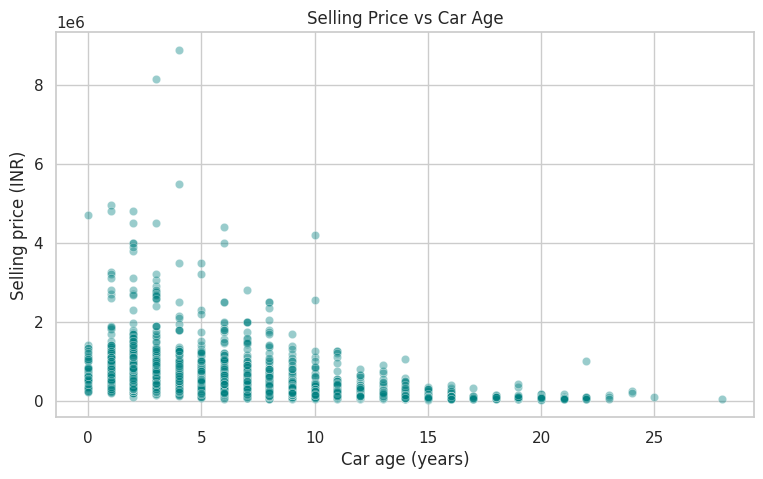

In [15]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x="car_age", y="selling_price", alpha=0.4, color="teal")
plt.title("Selling Price vs Car Age")
plt.xlabel("Car age (years)")
plt.ylabel("Selling price (INR)")
plt.show()

**Observation:** There is a clear **downward trend**. Newer cars sell for much more, and the price drops quickly in the first years and then levels off. The wide vertical spread at each age shows that age alone is not enough, and brand and other features also matter.

### 4.4 Additional views: transmission and brand

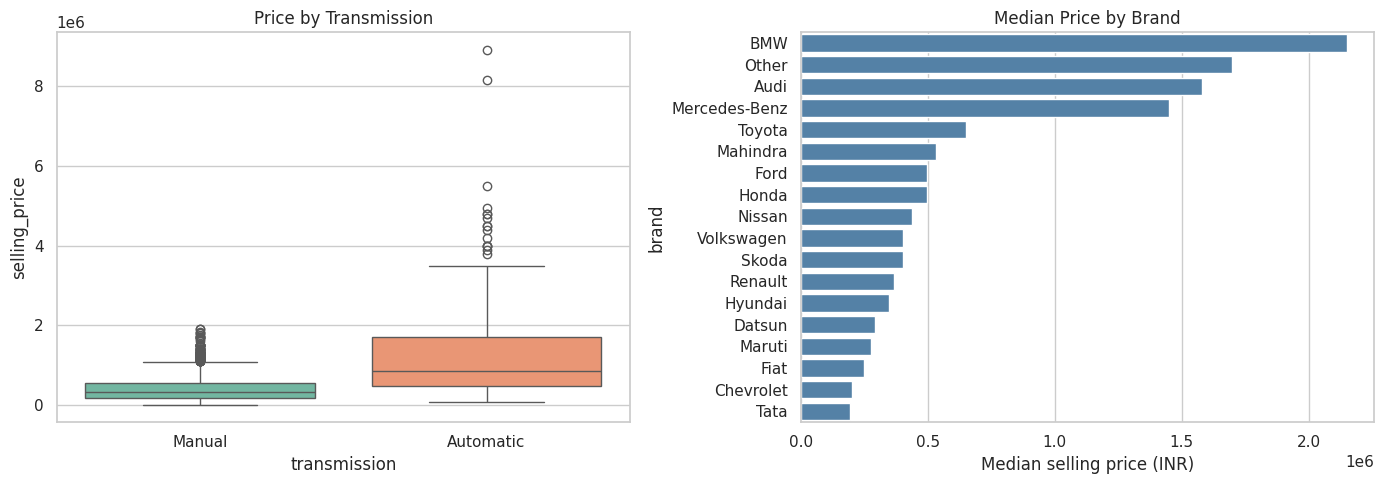

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="transmission", y="selling_price", palette="Set2", ax=axes[0])
axes[0].set_title("Price by Transmission")

order = df.groupby("brand")["selling_price"].median().sort_values(ascending=False).index
sns.barplot(data=df, y="brand", x="selling_price", order=order, estimator=np.median,
            errorbar=None, color="steelblue", ax=axes[1])
axes[1].set_title("Median Price by Brand")
axes[1].set_xlabel("Median selling price (INR)")

plt.tight_layout()
plt.show()

**Observation:** Automatic cars are priced much higher than manual ones, and luxury brands (Audi, BMW, Mercedes-Benz and others) sit far above mass-market brands such as Maruti and Datsun.

## 5. Encode Categorical Variables (One-Hot Encoding)
Machine learning models need numbers, so each category becomes its own 0/1 column. `drop_first=True` removes one redundant column per feature, which avoids the dummy-variable trap for Linear Regression.

In [17]:
categorical = ["brand", "fuel", "seller_type", "transmission", "owner"]

df_encoded = pd.get_dummies(df, columns=categorical, drop_first=True, dtype=int)

print("Shape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)
df_encoded.head()

Shape before encoding: (3575, 8)
Shape after encoding : (3575, 30)


,selling_price,km_driven,car_age,brand_BMW,brand_Chevrolet,brand_Datsun,brand_Fiat,brand_Ford,brand_Honda,brand_Hyundai,...,fuel_Diesel,fuel_Electric,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner
0,60000,70000,13,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,0,0
1,135000,50000,13,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,0,0
2,600000,100000,8,0,0,0,0,0,0,1,...,1,0,0,0,1,0,1,0,0,0
3,250000,46000,3,0,0,1,0,0,0,0,...,0,0,0,1,1,0,1,0,0,0
4,450000,141000,6,0,0,0,0,0,1,0,...,1,0,0,0,1,0,1,0,1,0


## 6. Feature Correlation Heatmap

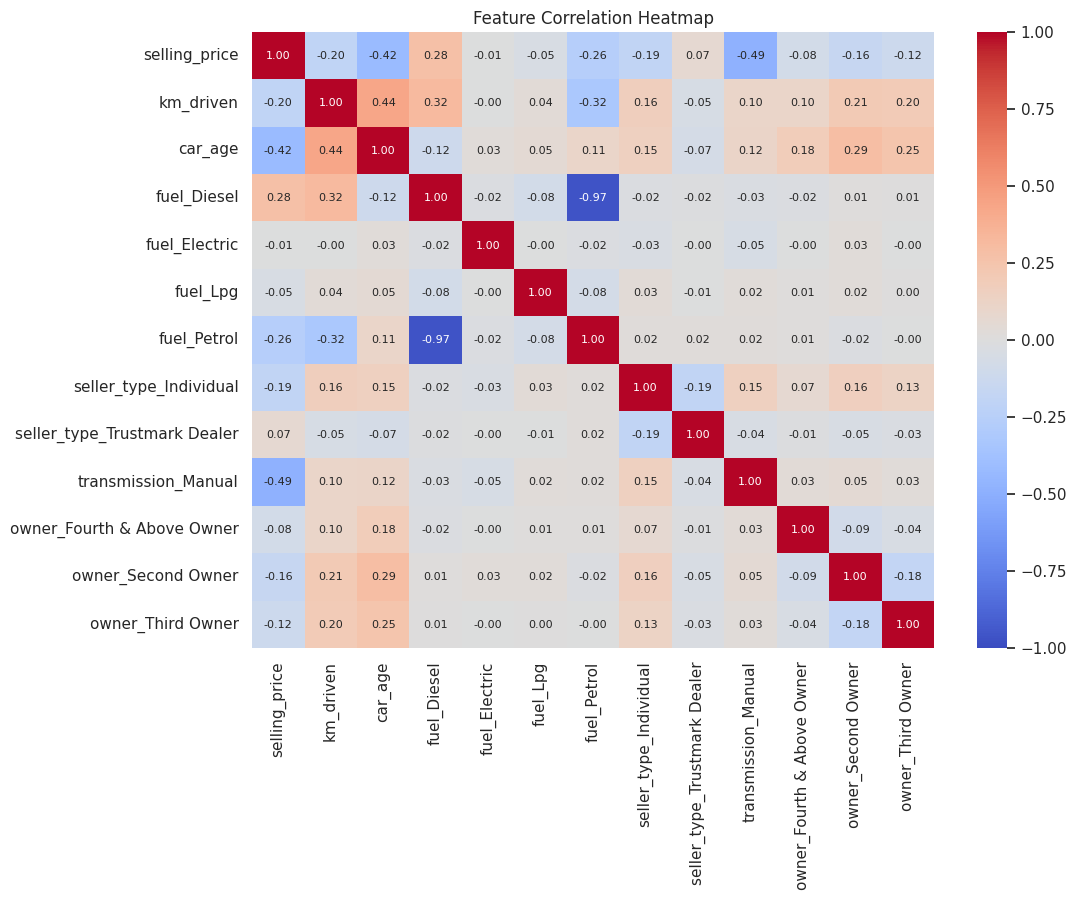

Correlation with selling price:
fuel_Diesel                     0.28
seller_type_Trustmark Dealer    0.07
fuel_Electric                  -0.01
fuel_Lpg                       -0.05
owner_Fourth & Above Owner     -0.08
owner_Third Owner              -0.12
owner_Second Owner             -0.16
seller_type_Individual         -0.19
km_driven                      -0.20
fuel_Petrol                    -0.26
car_age                        -0.42
transmission_Manual            -0.49
Name: selling_price, dtype: float64


In [18]:
# Brand columns are left out so the heatmap stays readable
corr_cols = [c for c in df_encoded.columns if not c.startswith("brand_")]

plt.figure(figsize=(11, 8))
sns.heatmap(df_encoded[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap")
plt.show()

print("Correlation with selling price:")
print(df_encoded[corr_cols].corr()["selling_price"].drop("selling_price").sort_values(ascending=False).round(2))

**Observations**
- **Car age** has a clear negative correlation with price: older cars are cheaper.
- **Automatic transmission** has a positive correlation with price.
- **Kilometres driven** has a weak negative correlation, since older cars tend to have more kilometres, so mileage and age partly overlap.
- Diesel and the owner categories show smaller effects.

## 7. Train/Test Split (80/20)

In [19]:
X = df_encoded.drop(columns="selling_price")
y = df_encoded["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

Training set: (2860, 29)
Test set    : (715, 29)


## 8. Train Regression Models
Three models are trained:
- **Linear Regression:** a simple baseline that assumes a straight-line relationship.
- **Random Forest Regressor:** many decision trees averaged together, which can capture non-linear patterns.
- **Gradient Boosting Regressor:** trees built one after another, each correcting the errors of the previous ones.

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                   max_depth=4, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")

Trained: Linear Regression


Trained: Random Forest


Trained: Gradient Boosting


## 9. Evaluate the Models
- **MAE** (Mean Absolute Error): the average size of the error, in rupees.
- **RMSE** (Root Mean Squared Error): similar to MAE but penalises large errors more.
- **R2:** the share of the variation in price the model explains (1.0 is perfect, 0 means no better than predicting the average).

In [21]:
results = []

for name, model in models.items():
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE (INR)": mean_absolute_error(y_test, pred_test),
        "RMSE (INR)": np.sqrt(mean_squared_error(y_test, pred_test)),
        "R2 (test)": r2_score(y_test, pred_test),
        "R2 (train)": r2_score(y_train, pred_train),
    })

results_df = pd.DataFrame(results).set_index("Model").sort_values("R2 (test)", ascending=False)
display(results_df.round(3))

,MAE (INR),RMSE (INR),R2 (test),R2 (train)
Model,,,,
Gradient Boosting,"155,361.95","349,777.18",0.62,0.85
Linear Regression,"183,574.47","378,411.55",0.55,0.62
Random Forest,"169,751.75","379,257.20",0.55,0.94


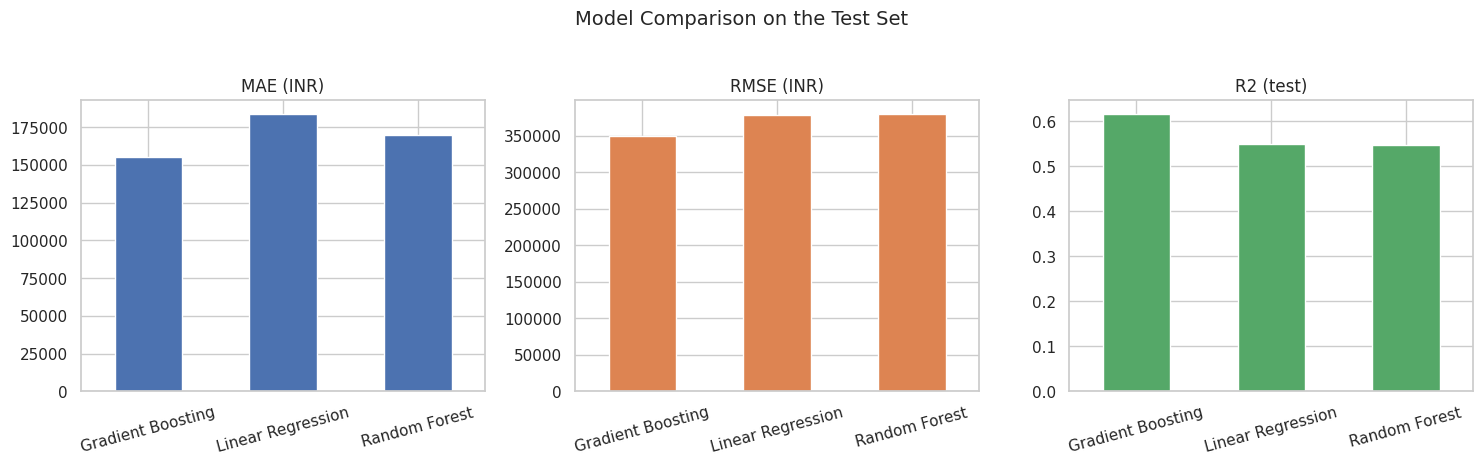

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, metric, color in zip(axes, ["MAE (INR)", "RMSE (INR)", "R2 (test)"],
                             ["#4C72B0", "#DD8452", "#55A868"]):
    results_df[metric].plot(kind="bar", ax=ax, color=color, rot=15)
    ax.set_title(metric)
    ax.set_xlabel("")

plt.suptitle("Model Comparison on the Test Set", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

### Actual vs predicted prices

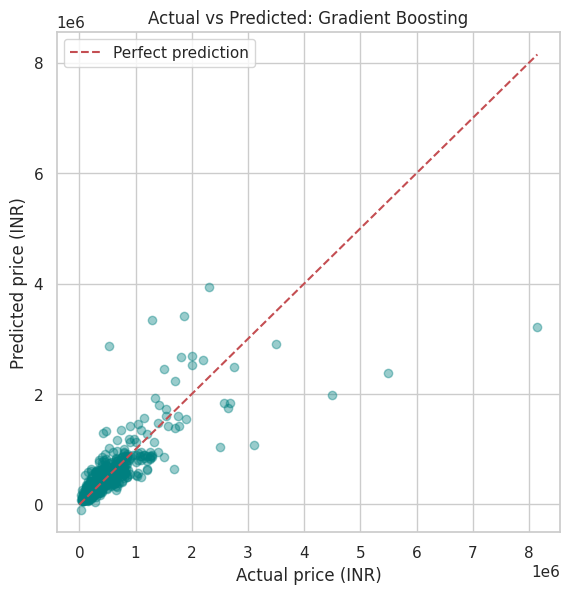

In [23]:
best_name = results_df.index[0]      # highest test R2
best_model = models[best_name]
best_pred = best_model.predict(X_test)

plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, best_pred, alpha=0.4, color="teal")
limit = max(y_test.max(), best_pred.max())
plt.plot([0, limit], [0, limit], "r--", label="Perfect prediction")
plt.xlabel("Actual price (INR)")
plt.ylabel("Predicted price (INR)")
plt.title(f"Actual vs Predicted: {best_name}")
plt.legend()
plt.show()

## 10. Feature Importance of the Best Model

Best model: Gradient Boosting


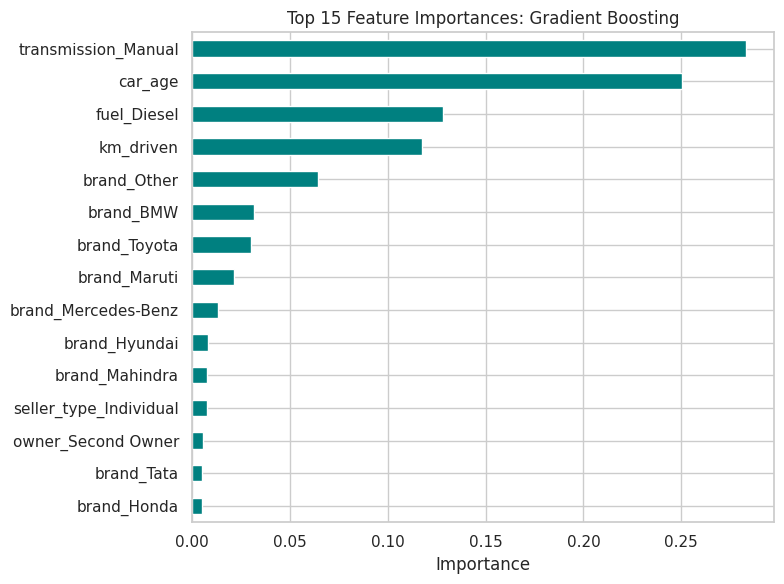

transmission_Manual   0.28
car_age               0.25
fuel_Diesel           0.13
km_driven             0.12
brand_Other           0.06
brand_BMW             0.03
brand_Toyota          0.03
brand_Maruti          0.02
dtype: float64


In [24]:
print(f"Best model: {best_name}")

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top = importances.head(15).sort_values()

plt.figure(figsize=(8, 6))
top.plot(kind="barh", color="teal")
plt.title(f"Top 15 Feature Importances: {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.head(8).round(3))

### Feature importance: what drives the price?
- **Transmission** (manual vs automatic) and **car age** are the two most important features (about 28% and 25%). Automatic cars and newer cars are clearly worth more.
- **Fuel type (diesel)** and **kilometres driven** come next (about 13% and 12%).
- **Brand** matters mainly for the premium makes. `brand_Other` groups rare, often premium, brands such as Jaguar, Land Rover and Volvo, and BMW also appears. Mass-market brands such as Maruti have small importance.
- Importances are split across one-hot columns, so a feature with many categories (like brand) looks smaller than its combined effect.

### Best model and justification
**Gradient Boosting** is declared the best model because it has the **lowest MAE and RMSE and the highest R2 on the unseen test data** (MAE about 155,000 INR, RMSE about 350,000 INR, R2 about 0.62).

- **Linear Regression** is the weakest on MAE (R2 about 0.55). It can only fit straight-line relationships, but car prices fall steeply and non-linearly with age and jump for luxury cars.
- **Random Forest** scores the same R2 as Linear Regression on the test set, yet reaches about 0.94 on the training set. That large gap means it **overfits**: it memorised the training cars and generalises worse.
- **Gradient Boosting** also overfits somewhat (train R2 about 0.85), but the gap is smaller and its test accuracy is the best.

**Limitations (honest reading of the results)**
- An R2 of about 0.62 means the model explains roughly 60% of the price variation, which is decent but not highly accurate.
- RMSE is much larger than MAE because a few expensive luxury cars produce very large errors, and the model struggles most with them.
- The dataset has no engine size, power, condition or exact model/variant details, which strongly affect price, so there is a ceiling on accuracy.
- Possible improvements: train on the logarithm of the price (in a quick test this improved Linear Regression to R2 of about 0.68), tune the hyperparameters, or extract more detail from the car name.

## 11. Predict the Price of a New Car
We can now use the best model to estimate the selling price of any car by giving its details.

*Note:* `car_age` is measured as of 2020 (see Section 3.1), and prices are 2020-era listing prices in INR.

In [1]:
def predict_price(brand, car_age, km_driven, fuel, seller_type, transmission, owner, model=best_model):
    """Estimate the selling price (INR) of a used car."""
    car = pd.DataFrame([{
        "km_driven": km_driven, "car_age": car_age, "brand": brand, "fuel": fuel,
        "seller_type": seller_type, "transmission": transmission, "owner": owner,
    }])
    # Apply the same encoding, then line the columns up with the training data
    car = pd.get_dummies(car, columns=categorical, dtype=int)
    car = car.reindex(columns=X.columns, fill_value=0)
    price = model.predict(car)[0]
    print(f"{brand}, {car_age} years old, {km_driven:,} km, {fuel}, {transmission}, {owner}")
    print(f"Estimated selling price: {price:,.0f} INR\n")
    return price

print("Valid brands:", sorted(df["brand"].unique()))
print("Valid fuel:", sorted(df["fuel"].unique()))
print("Valid owner:", sorted(df["owner"].unique()))
print("Valid seller_type:", sorted(df["seller_type"].unique()))
print()

# Try these examples, or change the values
predict_price("Skoda", 8, 60000, "Petrol", "Individual", "Manual", "First Owner")
predict_price("Hyundai", 5, 40000, "Diesel", "Dealer", "Manual", "First Owner")
predict_price("Toyota", 3, 25000, "Diesel", "Dealer", "Automatic", "First Owner")
predict_price("BMW", 4, 30000, "Diesel", "Dealer", "Automatic", "First Owner")

NameError: name 'best_model' is not defined

## Conclusion
- The data was cleaned (duplicates removed, categories standardised, impossible mileage values dropped) and two new features were engineered: **car age** and **brand**.
- EDA showed right-skewed prices, a strong drop in price with age, and clear price differences by fuel type, transmission and brand.
- Three regression models were trained and compared using MAE, RMSE and R2.
- The best model and the features that drive its predictions are discussed in Sections 9 and 10.